In [7]:
#Імпортуємо та завантажуємо все
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Стиль графіків
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Завантаження
df = pd.read_csv('Tesk_Task___Mail_Retention.csv', sep=';')
print(f"Рядків: {len(df):,}")
print(f"Колонки: {df.columns.tolist()}")
df.head(3)

Рядків: 27,090
Колонки: ['user_id', 'date', 'buyer', 'delivery_id', 'response', 'last_answer_timestamp', 'delivery_ts', 'send_ts', 'read_ts', 'click_ts', 'rule', 'confirm_timestamp', 'not_free_credits', 'total_credits', 'group_1', 'group_2', 'group_3', 'group_4']


,user_id,date,buyer,delivery_id,response,last_answer_timestamp,delivery_ts,send_ts,read_ts,click_ts,rule,confirm_timestamp,not_free_credits,total_credits,group_1,group_2,group_3,group_4
0,64643,06.10.2024,Not Buyer,730481110465188000,unread_unused_message,NaN,1.728226e+09,1.728226e+09,NaN,NaN,FH,2024-10-03 07:31:13.000000,NaN,NaN,Test,Control,Control,Test
1,72170,06.10.2024,Not Buyer,730481111996112000,unread_unused_message,NaN,1.728226e+09,1.728226e+09,NaN,NaN,FW,2024-08-22 19:26:07.000000,NaN,NaN,Test,Control,Control,Control
2,101003,06.10.2024,Not Buyer,730481121013510000,unread_unused_message,NaN,1.728226e+09,1.728226e+09,NaN,NaN,FD,2024-10-03 15:32:21.000000,NaN,NaN,Control,Control,Control,Control


In [8]:
# Підготовлюємо дані
# Конвертація дат і timestamp
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')

for col in ['send_ts', 'delivery_ts', 'read_ts', 'click_ts']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Бінарні флаги для воронки
df['is_delivered'] = df['delivery_ts'].notna().astype(int)
df['is_read']      = df['read_ts'].notna().astype(int)
df['is_clicked']   = df['click_ts'].notna().astype(int)
df['is_buyer']     = (df['buyer'] == 'Buyer').astype(int)
df['has_credits']  = df['not_free_credits'].notna().astype(int)

print("Готово. Перевірка флагів:")
print(df[['is_delivered','is_read','is_clicked','has_credits']].sum())

Готово. Перевірка флагів:
is_delivered    27074
is_read          7486
is_clicked        896
has_credits        17
dtype: int64


         Етап  Кількість  % від Sent  % від попереднього
         Sent      27090      100.00              100.00
    Delivered      27074       99.94               99.94
         Read       7486       27.63               27.65
      Clicked        896        3.31               11.97
Credits spent         17        0.06                1.90


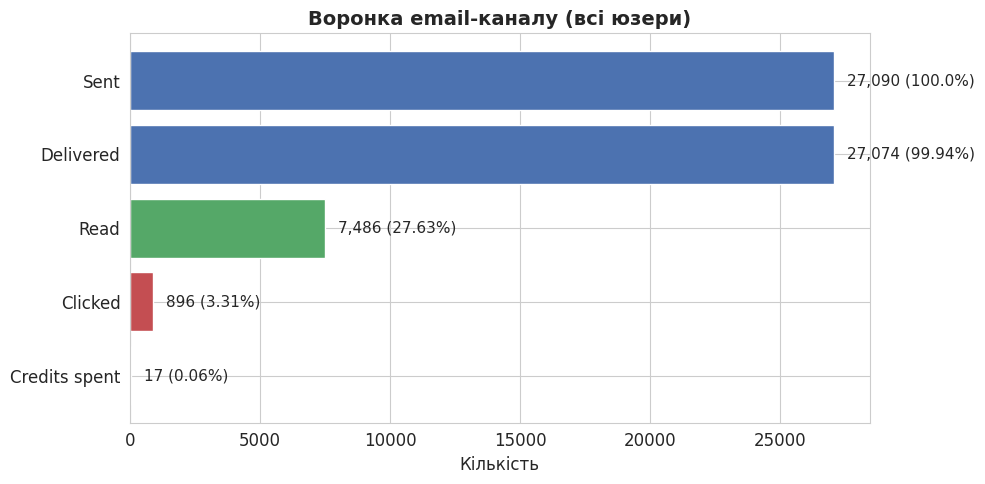

In [9]:
# Воронка Sent > Read > Click > Credits
total = len(df)
delivered = df['is_delivered'].sum()
read = df['is_read'].sum()
clicked = df['is_clicked'].sum()
credits = df['has_credits'].sum()

funnel = pd.DataFrame({
    'Етап': ['Sent', 'Delivered', 'Read', 'Clicked', 'Credits spent'],
    'Кількість': [total, delivered, read, clicked, credits],
})
funnel['% від Sent'] = (funnel['Кількість'] / total * 100).round(2)
funnel['% від попереднього'] = [
    100,
    round(delivered/total*100, 2),
    round(read/delivered*100, 2),
    round(clicked/read*100, 2) if read > 0 else 0,
    round(credits/clicked*100, 2) if clicked > 0 else 0,
]
print(funnel.to_string(index=False))

# Графік
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0','#4C72B0','#55A868','#C44E52','#8172B2']
bars = ax.barh(funnel['Етап'][::-1], funnel['Кількість'][::-1], color=colors[::-1])
for bar, val, pct in zip(bars, funnel['Кількість'][::-1], funnel['% від Sent'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({pct}%)", va='center', fontsize=11)
ax.set_title('Воронка email-каналу (всі юзери)', fontsize=14, fontweight='bold')
ax.set_xlabel('Кількість')
plt.tight_layout()
plt.savefig('funnel_overall.png', dpi=150)
plt.show()

    Група  Sent  Read rate %  Click rate %  Credits rate %
    Buyer  2654        34.97          8.29            0.53
Not Buyer 24436        26.84          2.77            0.01


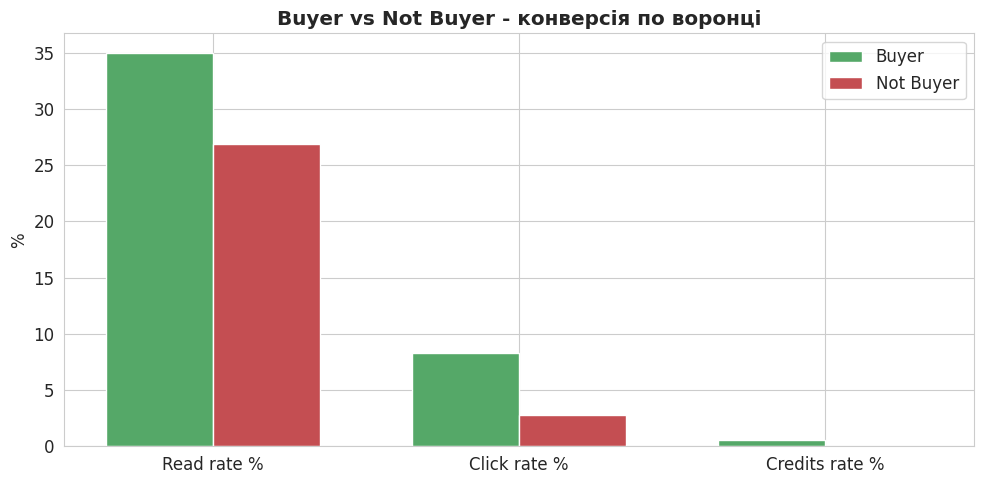

In [10]:
# Воронка Buyer vs Not Buyer
def funnel_for_group(mask, label):
    g = df[mask]
    n = len(g)
    return {
        'Група': label,
        'Sent': n,
        'Read rate %': round(g['is_read'].sum()/n*100, 2),
        'Click rate %': round(g['is_clicked'].sum()/n*100, 2),
        'Credits rate %': round(g['has_credits'].sum()/n*100, 2),
    }

funnel_compare = pd.DataFrame([
    funnel_for_group(df['is_buyer']==1, 'Buyer'),
    funnel_for_group(df['is_buyer']==0, 'Not Buyer'),
])
print(funnel_compare.to_string(index=False))

# Графік порівняння
metrics = ['Read rate %', 'Click rate %', 'Credits rate %']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, funnel_compare[funnel_compare['Група']=='Buyer'][metrics].values[0],
       width, label='Buyer', color='#55A868')
ax.bar(x + width/2, funnel_compare[funnel_compare['Група']=='Not Buyer'][metrics].values[0],
       width, label='Not Buyer', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('%')
ax.set_title('Buyer vs Not Buyer - конверсія по воронці', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('funnel_buyer_vs_notbuyer.png', dpi=150)
plt.show()

             response  sent  read_rate  click_rate  credits_rate  buyer_share
unread_unused_message  8929      31.96        6.34          0.18        11.29
          unread_used     1       0.00        0.00          0.00         0.00
  unread_used_message 17699      25.36        1.68          0.01         9.11
      welcome_message   461      31.24        6.94          0.00         7.38


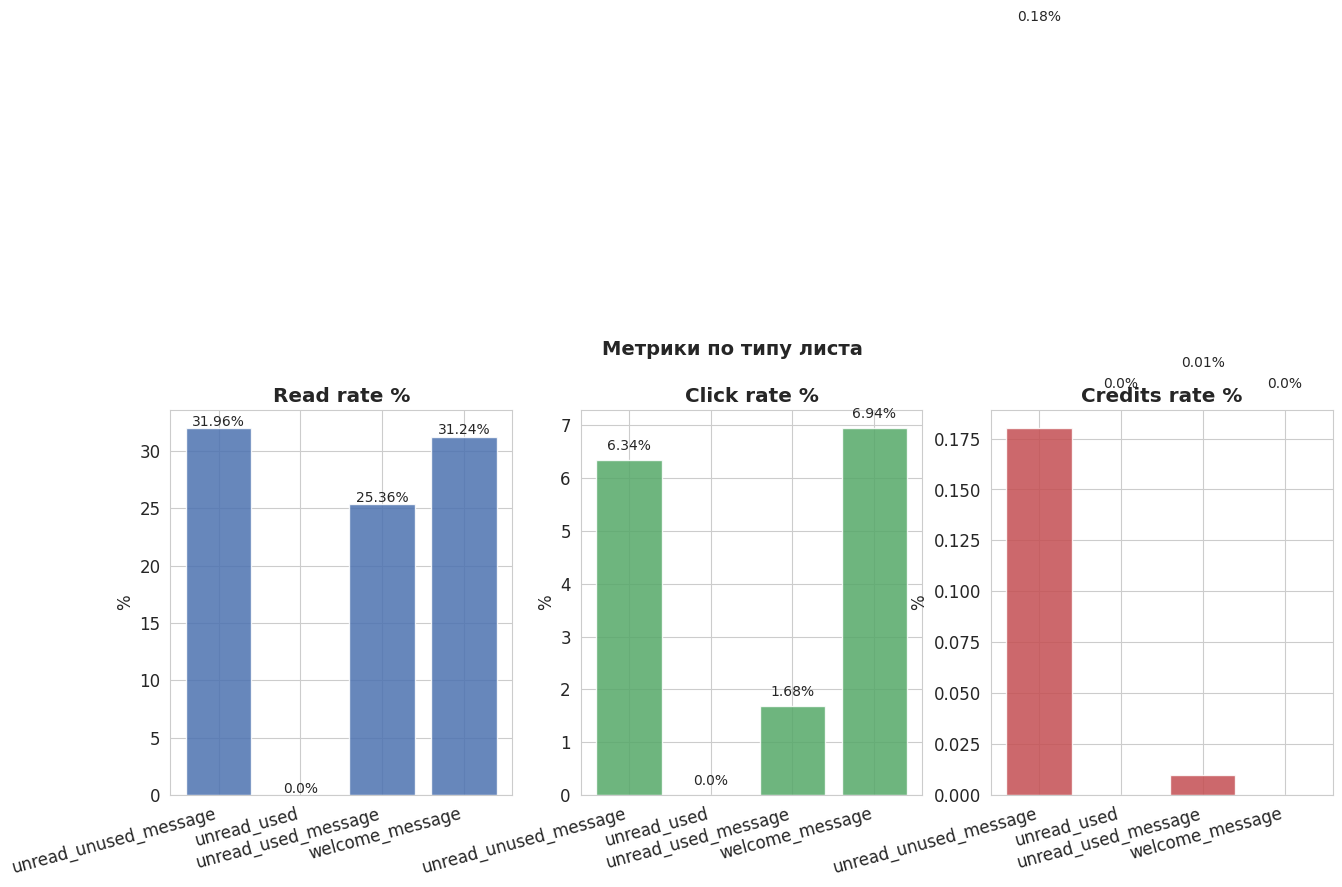

In [11]:
# Аналіз по типу листа (response)
response_stats = df.groupby('response').agg(
    sent=('user_id', 'count'),
    read_rate=('is_read', 'mean'),
    click_rate=('is_clicked', 'mean'),
    credits_rate=('has_credits', 'mean'),
    buyer_share=('is_buyer', 'mean'),
).reset_index()

for col in ['read_rate','click_rate','credits_rate','buyer_share']:
    response_stats[col] = (response_stats[col]*100).round(2)

print(response_stats.to_string(index=False))

# Графік
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_labels = [('read_rate','Read rate %'), ('click_rate','Click rate %'), ('credits_rate','Credits rate %')]
colors = ['#4C72B0','#55A868','#C44E52']

for ax, (metric, label), color in zip(axes, metrics_labels, colors):
    ax.bar(response_stats['response'], response_stats[metric], color=color, alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticklabels(response_stats['response'], rotation=15, ha='right')
    for i, v in enumerate(response_stats[metric]):
        ax.text(i, v + 0.2, f'{v}%', ha='center', fontsize=10)

plt.suptitle('Метрики по типу листа', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('response_type_analysis.png', dpi=150)
plt.show()

   rule  sent  read_rate  click_rate  credits_rate
     FH  2447      53.45       20.76          0.53
    New    97      53.61       16.49          0.00
     FD 16295      32.86        1.84          0.02
     SW   869       4.83        1.27          0.00
     FW  7253      10.05        0.84          0.00
History    89       0.00        0.00          0.00
     SM    39       0.00        0.00          0.00


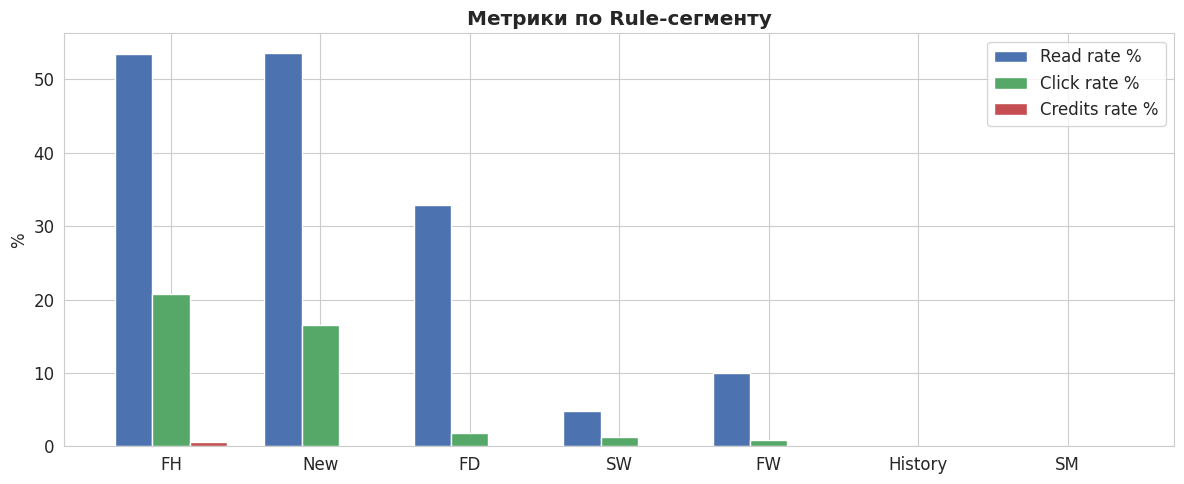

In [12]:
# Аналіз по Rule
rule_stats = df.groupby('rule').agg(
    sent=('user_id', 'count'),
    read_rate=('is_read', 'mean'),
    click_rate=('is_clicked', 'mean'),
    credits_rate=('has_credits', 'mean'),
).reset_index()

for col in ['read_rate','click_rate','credits_rate']:
    rule_stats[col] = (rule_stats[col]*100).round(2)

rule_stats = rule_stats.sort_values('click_rate', ascending=False)
print(rule_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rule_stats))
width = 0.25
ax.bar(x - width, rule_stats['read_rate'], width, label='Read rate %', color='#4C72B0')
ax.bar(x, rule_stats['click_rate'], width, label='Click rate %', color='#55A868')
ax.bar(x + width, rule_stats['credits_rate'], width, label='Credits rate %', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(rule_stats['rule'])
ax.set_ylabel('%')
ax.set_title('Метрики по Rule-сегменту', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('rule_analysis.png', dpi=150)
plt.show()

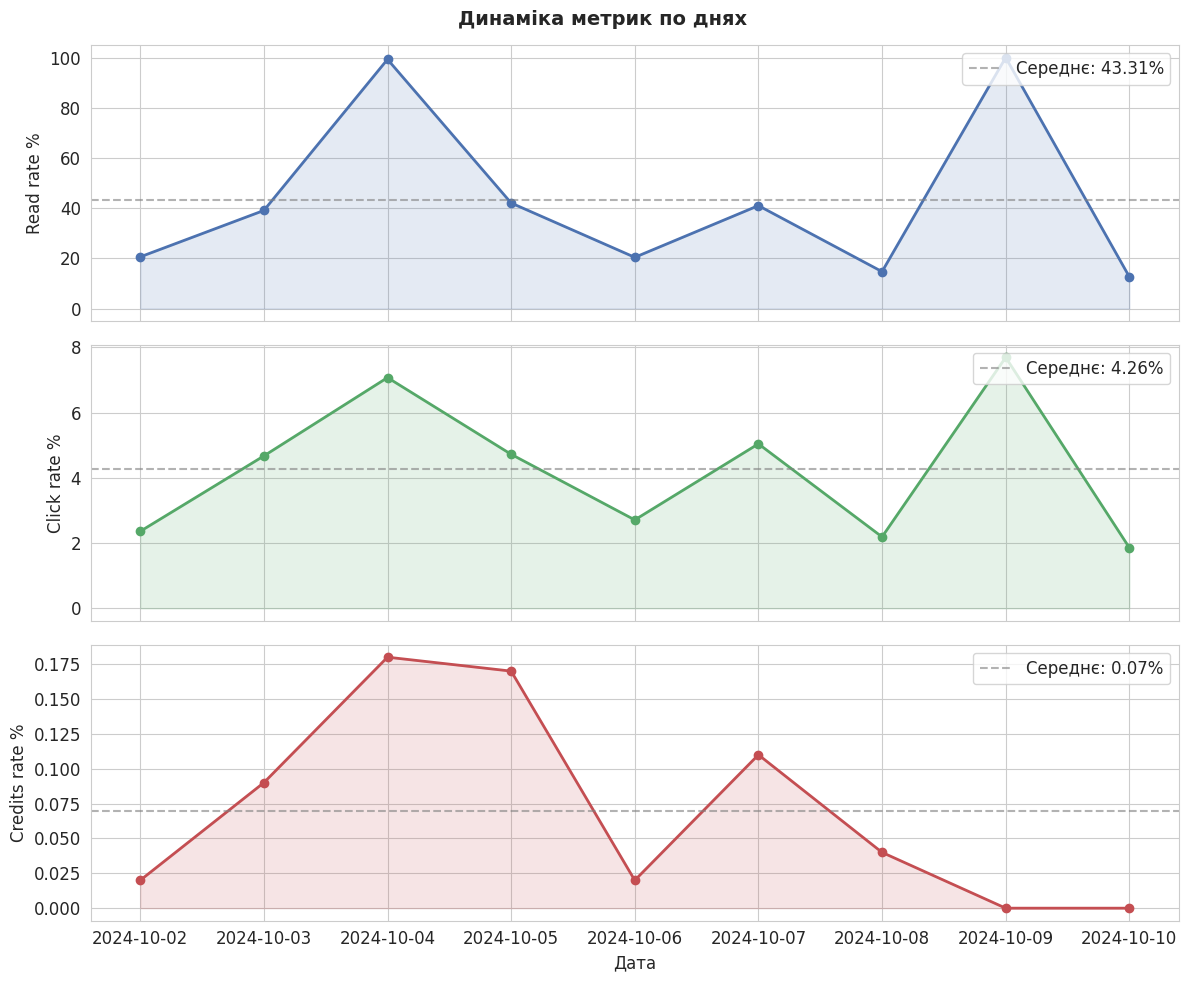

In [13]:
# Динаміка метрик по датах
daily = df.groupby('date').agg(
    sent=('user_id', 'count'),
    read_rate=('is_read', 'mean'),
    click_rate=('is_clicked', 'mean'),
    credits_rate=('has_credits', 'mean'),
).reset_index()

for col in ['read_rate','click_rate','credits_rate']:
    daily[col] = (daily[col]*100).round(2)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
metrics = [('read_rate','Read rate %','#4C72B0'),
           ('click_rate','Click rate %','#55A868'),
           ('credits_rate','Credits rate %','#C44E52')]

for ax, (metric, label, color) in zip(axes, metrics):
    ax.plot(daily['date'], daily[metric], marker='o', color=color, linewidth=2)
    ax.fill_between(daily['date'], daily[metric], alpha=0.15, color=color)
    mean_val = daily[metric].mean()
    ax.axhline(mean_val, linestyle='--', color='gray', alpha=0.6, label=f'Середнє: {mean_val:.2f}%')
    ax.set_ylabel(label)
    ax.legend(loc='upper right')

axes[2].set_xlabel('Дата')
plt.suptitle('Динаміка метрик по днях', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('daily_dynamics.png', dpi=150)
plt.show()

In [14]:
# A/B аналіз по всіх 4 групах
def ab_analysis(group_col):
    g = df.groupby(group_col).agg(
        sent=('user_id', 'count'),
        read_rate=('is_read', 'mean'),
        click_rate=('is_clicked', 'mean'),
        credits_rate=('has_credits', 'mean'),
        buyer_share=('is_buyer', 'mean'),
    ).reset_index()

    for col in ['read_rate','click_rate','credits_rate','buyer_share']:
        g[col] = (g[col]*100).round(2)

    return g

groups_summary = {}
for g in ['group_1','group_2','group_3','group_4']:
    groups_summary[g] = ab_analysis(g)
    print(f"\n=== {g.upper()} ===")
    print(groups_summary[g].to_string(index=False))


=== GROUP_1 ===
group_1  sent  read_rate  click_rate  credits_rate  buyer_share
Control 13441      27.24        2.86          0.04         9.62
   Test 13648      28.03        3.74          0.08         9.97

=== GROUP_2 ===
group_2  sent  read_rate  click_rate  credits_rate  buyer_share
Control 13121      27.73        3.75          0.05         9.37
   Test 13968      27.55        2.89          0.08        10.19

=== GROUP_3 ===
group_3  sent  read_rate  click_rate  credits_rate  buyer_share
Control 13195      27.15        3.33          0.04         9.77
   Test 13894      28.09        3.28          0.09         9.82

=== GROUP_4 ===
group_4  sent  read_rate  click_rate  credits_rate  buyer_share
Control 13538      27.87        3.36          0.04        10.01
   Test 13551      27.40        3.25          0.08         9.59


In [15]:
# Chi-square тест для кожної групи
from scipy.stats import chi2_contingency

def chi_square_test(group_col, metric_col):
    test = df[df[group_col] == 'Test'][metric_col]
    control = df[df[group_col] == 'Control'][metric_col]

    contingency = np.array([
        [test.sum(), len(test) - test.sum()],
        [control.sum(), len(control) - control.sum()]
    ])

    chi2, p, dof, _ = chi2_contingency(contingency)

    test_rate = test.mean() * 100
    control_rate = control.mean() * 100
    lift = ((test_rate - control_rate) / control_rate * 100) if control_rate > 0 else 0

    return {
        'Test rate %': round(test_rate, 2),
        'Control rate %': round(control_rate, 2),
        'Lift %': round(lift, 2),
        'p-value': round(p, 4),
        'Значущий (p<0.05)': '✅ Так' if p < 0.05 else '❌ Ні',
    }

metrics = {
    'Read rate': 'is_read',
    'Click rate': 'is_clicked',
    'Credits rate': 'has_credits',
}

print("=" * 70)
for group in ['group_1','group_2','group_3','group_4']:
    print(f"\n{'='*70}")
    print(f"  {group.upper()}")
    print(f"{'='*70}")
    results = []
    for metric_name, metric_col in metrics.items():
        row = chi_square_test(group, metric_col)
        row['Метрика'] = metric_name
        results.append(row)
    res_df = pd.DataFrame(results)[['Метрика','Control rate %','Test rate %','Lift %','p-value','Значущий (p<0.05)']]
    print(res_df.to_string(index=False))


  GROUP_1
     Метрика  Control rate %  Test rate %  Lift %  p-value Значущий (p<0.05)
   Read rate           27.24        28.03    2.90   0.1506              ❌ Ні
  Click rate            2.86         3.74   30.71   0.0001             ✅ Так
Credits rate            0.04         0.08   80.55   0.3478              ❌ Ні

  GROUP_2
     Метрика  Control rate %  Test rate %  Lift %  p-value Значущий (p<0.05)
   Read rate           27.73        27.55   -0.64   0.7539              ❌ Ні
  Click rate            3.75         2.89  -22.87   0.0001             ✅ Так
Credits rate            0.05         0.08   72.22   0.3998              ❌ Ні

  GROUP_3
     Метрика  Control rate %  Test rate %  Lift %  p-value Значущий (p<0.05)
   Read rate           27.15        28.09    3.45   0.0872              ❌ Ні
  Click rate            3.33         3.28   -1.58   0.8352              ❌ Ні
Credits rate            0.04         0.09  127.93   0.1771              ❌ Ні

  GROUP_4
     Метрика  Control rate %  Te

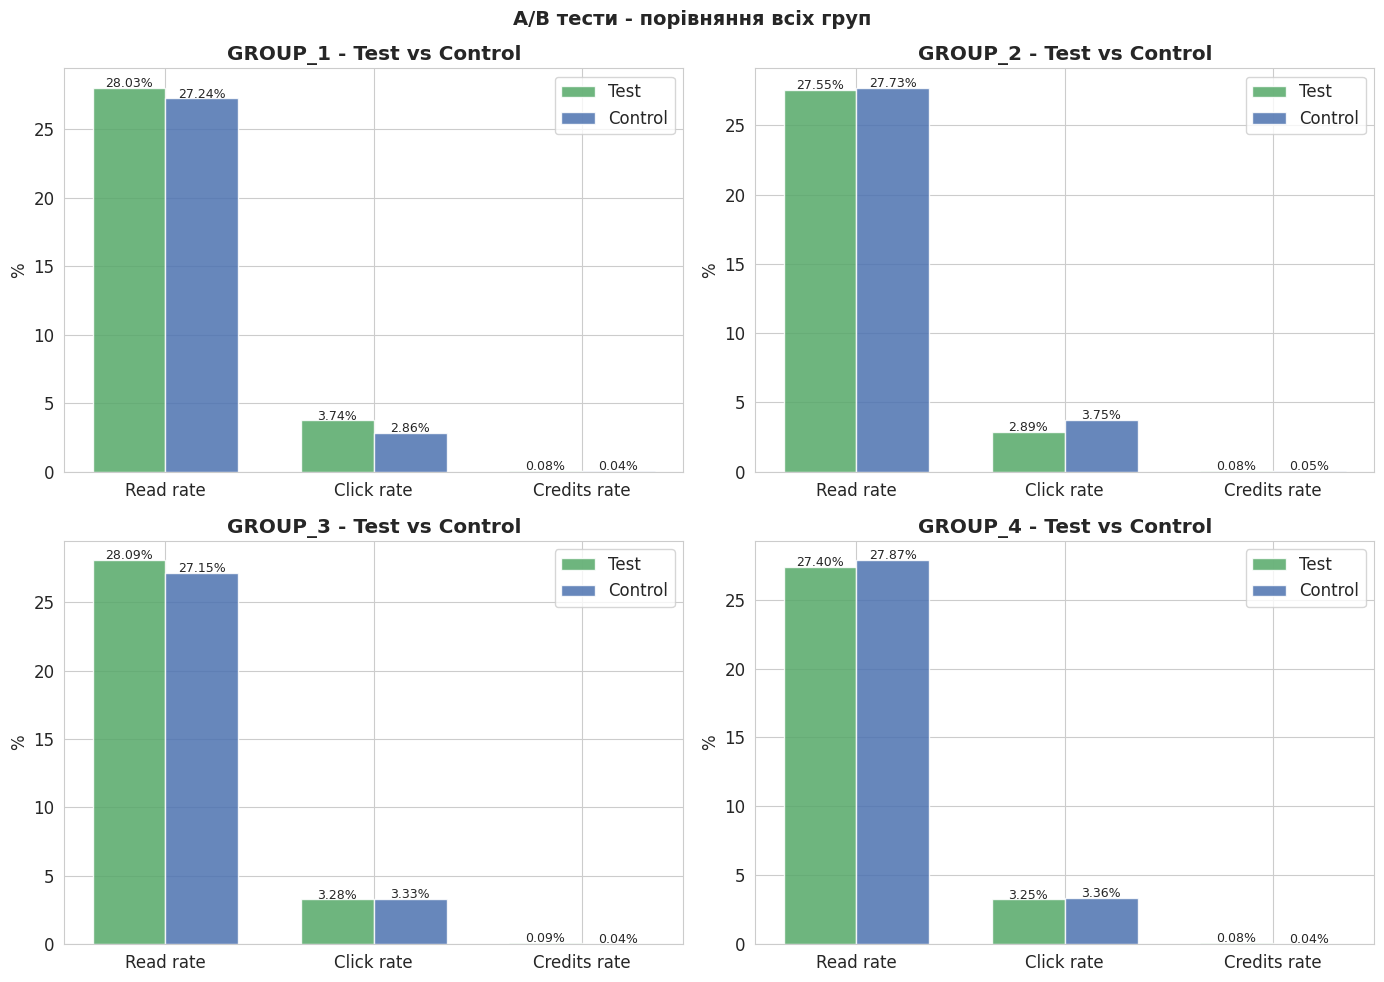

In [16]:
# Візуалізація A/B результатів
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, group in enumerate(['group_1','group_2','group_3','group_4']):
    ax = axes[idx]

    metrics_vals = {}
    for metric_name, metric_col in metrics.items():
        test_rate = df[df[group]=='Test'][metric_col].mean() * 100
        control_rate = df[df[group]=='Control'][metric_col].mean() * 100
        metrics_vals[metric_name] = {'Test': test_rate, 'Control': control_rate}

    x = np.arange(len(metrics))
    width = 0.35

    test_vals = [metrics_vals[m]['Test'] for m in metrics]
    control_vals = [metrics_vals[m]['Control'] for m in metrics]

    bars1 = ax.bar(x - width/2, test_vals, width, label='Test', color='#55A868', alpha=0.85)
    bars2 = ax.bar(x + width/2, control_vals, width, label='Control', color='#4C72B0', alpha=0.85)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.2f}%', ha='center', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.2f}%', ha='center', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(list(metrics.keys()))
    ax.set_ylabel('%')
    ax.set_title(f'{group.upper()} - Test vs Control', fontweight='bold')
    ax.legend()

plt.suptitle('A/B тести - порівняння всіх груп', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_tests.png', dpi=150)
plt.show()

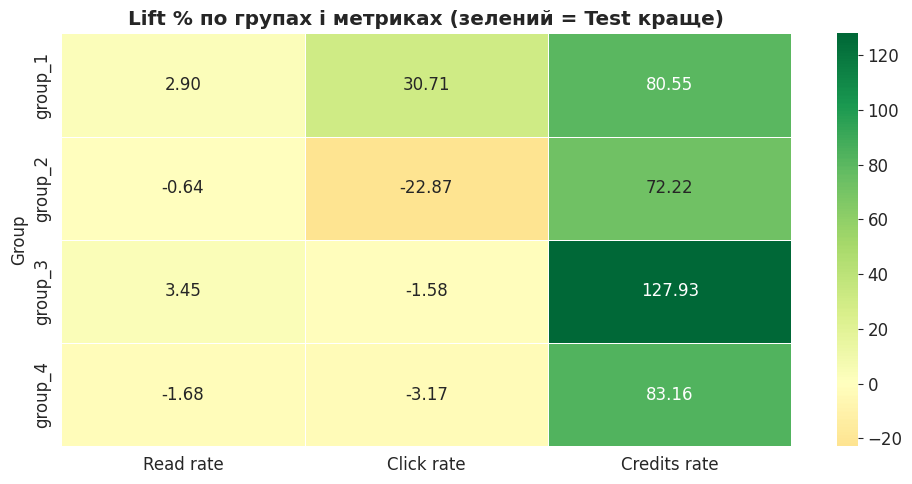

In [17]:
# Heatmap значущості
heatmap_data = []

for group in ['group_1','group_2','group_3','group_4']:
    row = {'Group': group}
    for metric_name, metric_col in metrics.items():
        result = chi_square_test(group, metric_col)
        row[metric_name] = result['Lift %']
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data).set_index('Group')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 12}
)
ax.set_title('Lift % по групах і метриках (зелений = Test краще)', fontweight='bold')
plt.tight_layout()
plt.savefig('ab_heatmap.png', dpi=150)
plt.show()

In [19]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           КЛЮЧОВІ ІНСАЙТИ - Mail Retention EDA              ║
╚══════════════════════════════════════════════════════════════╝

ВОРОНКА
- Delivery rate майже ідеальний: 99.94% листів доходить до юзерів
- Головний drop-off: Delivered → Read (лише 27.63% відкривають лист)
- Click rate від Sent: 3.31% - з тих хто прочитав клікає 11.97%
- Credits spent критично низький: 0.06% - email-канал майже не конвертує в покупку

BUYER vs NOT BUYER
- Buyer читає листи частіше: 34.97% vs 26.84% у Not Buyer (+30% різниця)
- Click rate у Buyer в 3x вищий: 8.29% vs 2.77%
- Credits rate у Buyer в 53x вищий: 0.53% vs 0.01%
- Висновок: email-канал ефективний для утримання платників, але майже не конвертує нових

ТИП ЛИСТА
- unread_unused_message: read rate 31.96%, click rate 6.34% - найкраще залучення
- welcome_message: read rate 31.24%, click rate 6.94% - найвищий CTR з усіх типів
- unread_used_message: read rate 25.36%, click rate лише 1.68% - найгірший результат
- Висновок: листи про непрочитані нові повідомлення (unused) працюють краще ніж нагадування про старі (used)

RULE-СЕГМЕНТИ
- FH і New: лідери по read rate (~53%) і click rate (20.76% та 16.49%)
- FD: найбільший сегмент (16,295 відправок) але середній результат - read 32.86%, click 1.84%
- History і SM: нульові показники по всіх метриках - сегменти не працюють взагалі
- FW: великий сегмент (7,253) але слабкий read rate 10.05% і click rate 0.84%
- Висновок: FH і New дають найякісніший трафік, FW і FD потребують оптимізації

A/B ТЕСТИ
- Group_1: єдиний значущий результат - click rate +30.71% (p=0.0001) на користь Test ✅
- Group_2: click rate впав на -22.87% у Test (p=0.0001) - тест шкідливий, зупиняти ❌
- Group_3: жодна метрика не досягла значущості (p>0.05) - недостатньо даних або слабкий ефект
- Group_4: жодна метрика не значуща - тест не показав результату

ГІПОТЕЗИ ДЛЯ МАЙБУТНІХ ТЕСТІВ
1. FW сегмент має великий об'єм але низький read rate (10%) - тестувати зміну subject line
   або часу відправки для підвищення open rate
2. unread_used_message має click rate в 3.8x нижчий ніж unused - тестувати обмеження
   частоти відправки до 1 листа на 3 дні щоб не "спалювати" аудиторію
3. welcome_message має найвищий CTR (6.94%) але нульовий credits rate -
   тестувати додавання прямого CTA на покупку кредитів у welcome листі
4. History і SM сегменти повністю неефективні - тестувати повне відключення
   або радикальну зміну контенту для цих груп
5. Group_1 показала реальний lift по кліках - масштабувати цю зміну на всю аудиторію
   і відстежити чи конвертується в credits spend
""")


╔══════════════════════════════════════════════════════════════╗
║           КЛЮЧОВІ ІНСАЙТИ - Mail Retention EDA              ║
╚══════════════════════════════════════════════════════════════╝

ВОРОНКА
- Delivery rate майже ідеальний: 99.94% листів доходить до юзерів
- Головний drop-off: Delivered → Read (лише 27.63% відкривають лист)
- Click rate від Sent: 3.31% - з тих хто прочитав клікає 11.97%
- Credits spent критично низький: 0.06% - email-канал майже не конвертує в покупку

BUYER vs NOT BUYER
- Buyer читає листи частіше: 34.97% vs 26.84% у Not Buyer (+30% різниця)
- Click rate у Buyer в 3x вищий: 8.29% vs 2.77%
- Credits rate у Buyer в 53x вищий: 0.53% vs 0.01%
- Висновок: email-канал ефективний для утримання платників, але майже не конвертує нових

ТИП ЛИСТА
- unread_unused_message: read rate 31.96%, click rate 6.34% - найкраще залучення
- welcome_message: read rate 31.24%, click rate 6.94% - найвищий CTR з усіх типів
- unread_used_message: read rate 25.36%, click rate лише 1.